In [0]:
osha = spark.read.table('default.osha')

In [0]:
osha = osha.na.drop(subset=["annual_average_employees",
                            "total_hours_worked",
                            "total_injuries",
                            "Industry Name",
                            "state"])

(oshaTrain, oshaTest) = osha.randomSplit([0.8,0.2])

In [0]:
from pyspark.sql.functions import log1p, col, when
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline

oshaTrain = oshaTrain.withColumn("log_hours", log1p(col("total_hours_worked")))

cat_cols   = ["state", "Industry Name"]
indexers   = [StringIndexer(inputCol=c, outputCol=f"{c}_idx",
                            handleInvalid="keep") for c in cat_cols]
encoders   = [OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_vec")
              for c in cat_cols]

num_cols   = ["annual_average_employees", "total_hours_worked"]

assembler  = VectorAssembler(
                inputCols=[f"{c}_vec" for c in cat_cols] + num_cols,
                outputCol="features")


In [0]:
from pyspark.ml.evaluation import RegressionEvaluator

Decision Tree

In [0]:
from pyspark.ml.regression import DecisionTreeRegressor

In [0]:
dt = DecisionTreeRegressor(labelCol="total_injuries", featuresCol="features") 

In [0]:
pipeline = Pipeline(stages=indexers + encoders + [assembler, dt])
model    = pipeline.fit(oshaTrain)
preds    = model.transform(oshaTest)

In [0]:
preds.show()

+-------+--------------------+--------------------+---------+--------------------+--------------+-----+--------+----------+--------------------+------------------------+------------------+---------------------+------------+----------------+----------------+-----------------+---------------+---------------+--------------+----------------+----------------------------+--------------------+------------------+---------------------+----------------+------------------+----+---------------+--------+--------------------+---------+--------------------+---------+-----------------+---------------+-----------------+--------------------+-------------------+
|     id|        company_name|  establishment_name|      ein|      street_address|          city|state|zip_code|naics_code|industry_description|annual_average_employees|total_hours_worked|no_injuries_illnesses|total_deaths|total_dafw_cases|total_djtr_cases|total_other_cases|total_dafw_days|total_djtr_days|total_injuries|total_poisonings|total_res

In [0]:
rmse_evaluator = RegressionEvaluator(
                     labelCol="total_injuries",
                     predictionCol="prediction",
                     metricName="rmse")

mae_evaluator  = RegressionEvaluator(
                     labelCol="total_injuries",
                     predictionCol="prediction",
                     metricName="mae")

rmse = rmse_evaluator.evaluate(preds)
mae  = mae_evaluator.evaluate(preds)

print(f"RMSE : {rmse:0.4f}")
print(f"MAE  : {mae:0.4f}")

RMSE : 12.4611
MAE  : 3.0063


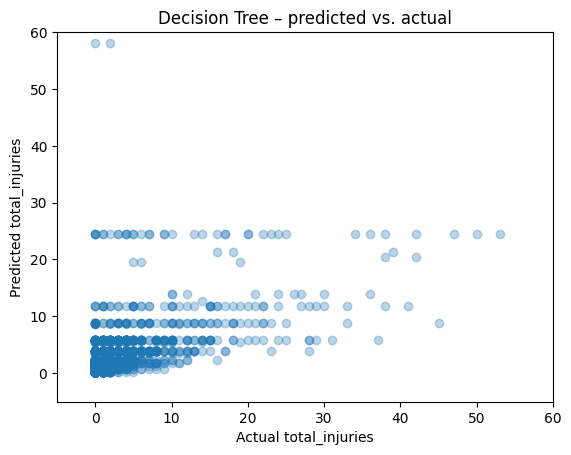

In [0]:
from pyspark.sql import functions as F

(sample_pd, _) = preds.orderBy(F.rand()).limit(2000).toPandas(), None

import matplotlib.pyplot as plt
plt.scatter(sample_pd["total_injuries"], sample_pd["prediction"], alpha=0.3)
plt.xlabel("Actual total_injuries")
plt.ylabel("Predicted total_injuries")
plt.title("Decision Tree – predicted vs. actual")
plt.xlim(xmin=-5,xmax=60)
plt.ylim(ymin=-5,ymax=60)
plt.show()

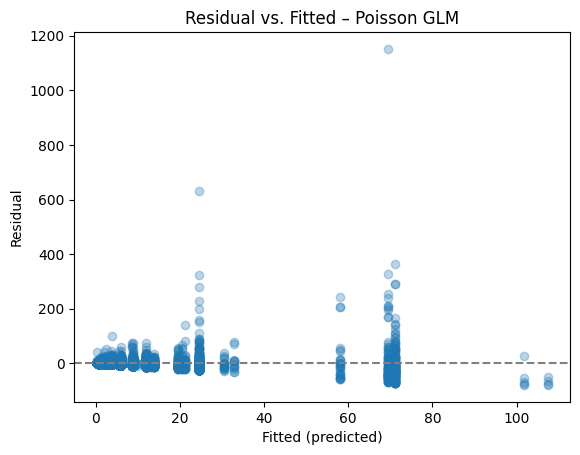

In [0]:
sample = preds.select("prediction", "total_injuries") \
                 .withColumn("resid", F.col("total_injuries") - F.col("prediction")) \
                 .sample(0.1, seed=42)
pdf    = sample.toPandas()

plt.scatter(pdf["prediction"], pdf["resid"], alpha=0.3)
plt.axhline(0, color="grey", ls="--")
plt.xlabel("Fitted (predicted)")
plt.ylabel("Residual")
plt.title("Residual vs. Fitted – Poisson GLM")
plt.show()

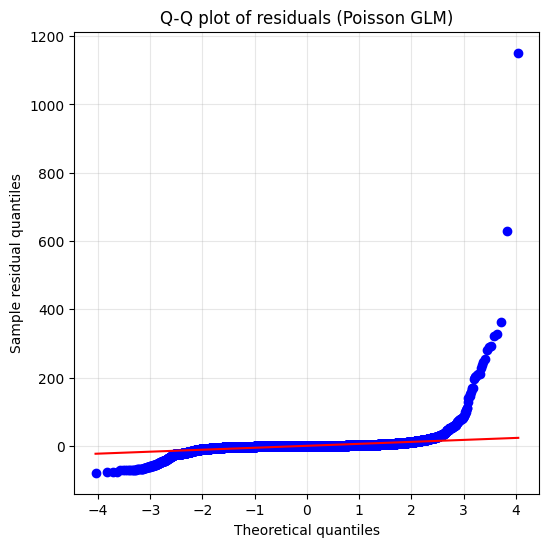

In [0]:
resid_pd = (
    preds
    .select( (F.col("total_injuries") - F.col("prediction")).alias("resid") )
    .sample(0.1, seed=42)
    .toPandas()
)

import scipy.stats as stats

plt.figure(figsize=(6, 6))
stats.probplot(resid_pd["resid"], dist="norm", plot=plt)
plt.title("Q-Q plot of residuals (Poisson GLM)")
plt.xlabel("Theoretical quantiles")
plt.ylabel("Sample residual quantiles")
plt.grid(True, alpha=0.3)
plt.show()

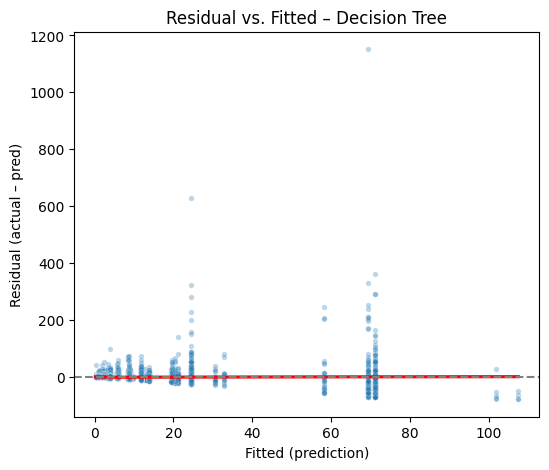

In [0]:
sample = (preds
          .select("prediction", "total_injuries")
          .withColumn("resid", F.col("total_injuries") - F.col("prediction"))
          .sample(0.1, seed=42)
          .toPandas())

import seaborn as sns

plt.figure(figsize=(6,5))
sns.scatterplot(x="prediction", y="resid", data=sample, alpha=0.3, s=15)
sns.regplot(x="prediction", y="resid", data=sample,
            scatter=False, lowess=True, color="red")
plt.axhline(0, ls="--", c="grey")
plt.xlabel("Fitted (prediction)")
plt.ylabel("Residual (actual – pred)")
plt.title("Residual vs. Fitted – Decision Tree")
plt.show()
